In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans,AgglomerativeClustering

In [2]:
mall = pd.read_csv('./Mall_Customers.csv')
mall

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
mall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
mall.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
mall.mean(numeric_only=True)

CustomerID                100.50
Age                        38.85
Annual Income (k$)         60.56
Spending Score (1-100)     50.20
dtype: float64

In [6]:
mall.median(numeric_only=True)

CustomerID                100.5
Age                        36.0
Annual Income (k$)         61.5
Spending Score (1-100)     50.0
dtype: float64

In [7]:
mall = mall.drop(columns='CustomerID')

In [8]:
(mall.isnull()).sum()

Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
mall.mode()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Female,32.0,54,42.0
1,NaN,NaN,78,NaN


<AxesSubplot: xlabel='Age', ylabel='Count'>

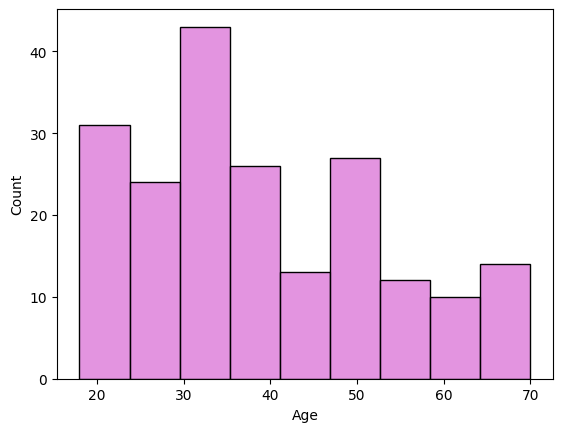

In [10]:
sns.histplot(data=mall,x=mall['Age'],color='Orchid')

<AxesSubplot: xlabel='Annual Income (k$)', ylabel='Count'>

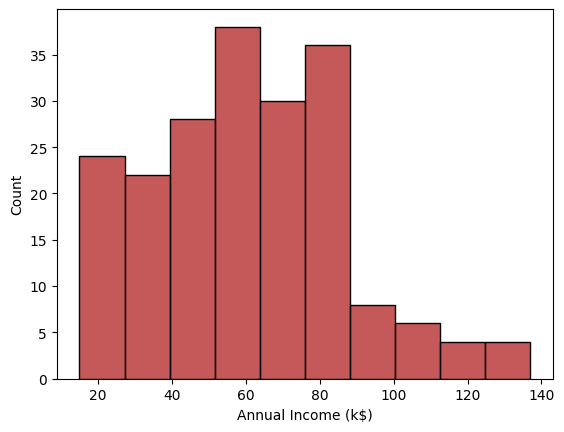

In [11]:
sns.histplot(data=mall,x=mall['Annual Income (k$)'],color='firebrick')

<AxesSubplot: xlabel='Spending Score (1-100)', ylabel='Count'>

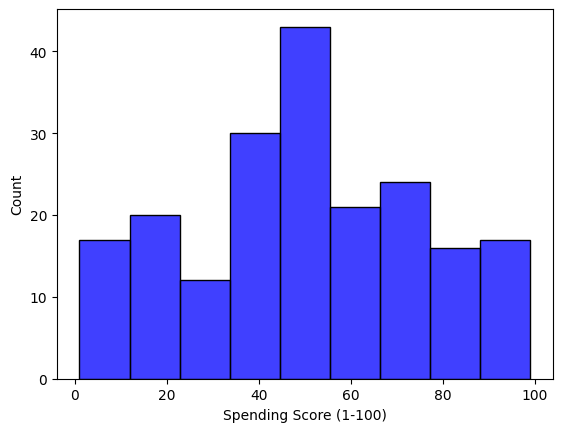

In [12]:
sns.histplot(data=mall,x=mall['Spending Score (1-100)'],color='blue')

<AxesSubplot: >

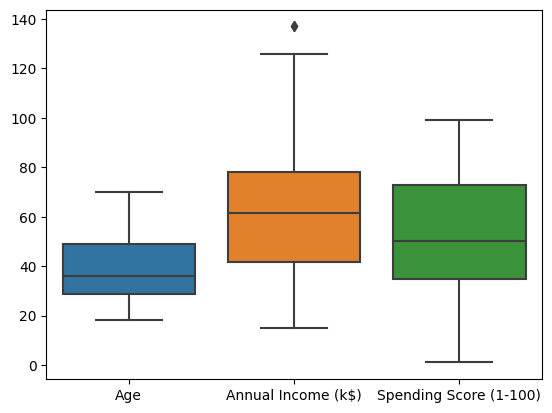

In [13]:
sns.boxplot(data=mall)

In [14]:
df1 = mall[['Annual Income (k$)','Spending Score (1-100)']]
df1

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


<AxesSubplot: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

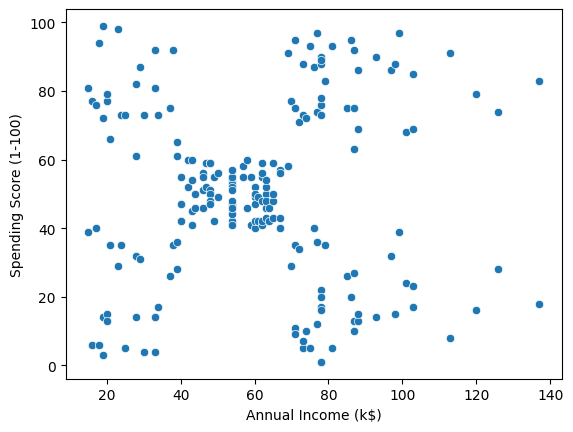

In [15]:
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'],y=df1['Spending Score (1-100)'])

In [16]:
clust = KMeans(n_clusters=3)

In [17]:
clust.fit(df1)

KMeans(n_clusters=3)

In [18]:
clustered = clust.predict(df1)

In [19]:
clust.cluster_centers_


array([[87.        , 18.63157895],
       [86.53846154, 82.12820513],
       [44.15447154, 49.82926829]])

In [20]:
clust.inertia_


106348.37306211119

In [21]:
clust.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1], dtype=int32)

<AxesSubplot: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

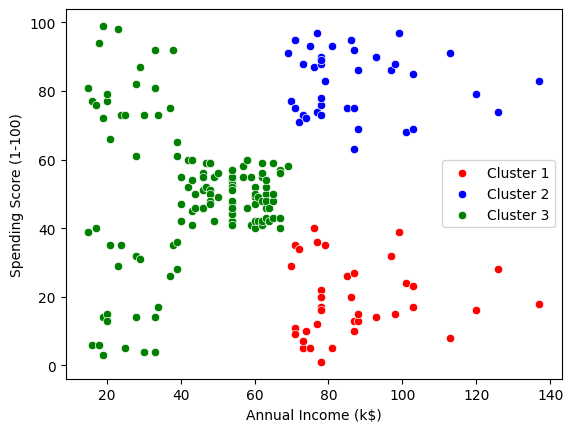

In [22]:
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'][clust.labels_ == 0],y=df1['Spending Score (1-100)'][clust.labels_ ==0],label='Cluster 1',c='red')
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'][clust.labels_ == 1],y=df1['Spending Score (1-100)'][clust.labels_ ==1],label='Cluster 2',c='blue')
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'][clust.labels_ == 2],y=df1['Spending Score (1-100)'][clust.labels_ ==2],label='Cluster 3',c='green')

In [23]:
inert_list = []
for x in range (1,16):
    testClust = KMeans(n_clusters=x)
    testClust.fit_predict(df1)
    inert_list.append(testClust.inertia_)
inert_list

[269981.2800000001,
 181363.59595959596,
 106348.3730621112,
 73679.78903948834,
 44448.45544793371,
 37233.81451071001,
 30241.343617936585,
 25018.576334776335,
 21838.863692828912,
 20072.56454320873,
 17595.28888108518,
 15838.717785514085,
 14293.143054331289,
 12825.554989618224,
 11728.346236194895]

<AxesSubplot: >

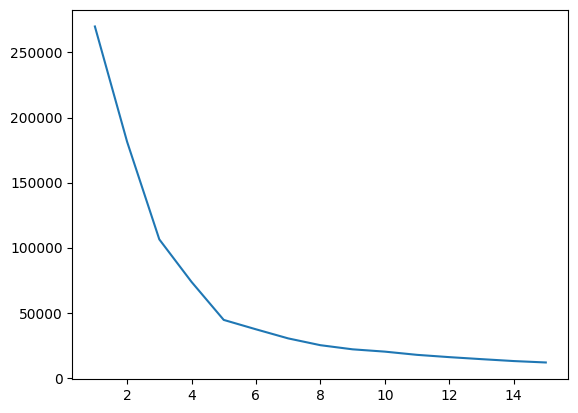

In [24]:
sns.lineplot(x=list(range(1,16)),y=inert_list)

In [25]:
betterClust = KMeans(n_clusters=5)
betterClust.fit(df1)

KMeans(n_clusters=5)

In [26]:
betterClust.predict(df1)


array([3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 1,
       3, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 4, 2, 1, 2, 4, 2, 4, 2,
       1, 2, 4, 2, 4, 2, 4, 2, 4, 2, 1, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2], dtype=int32)

In [27]:
betterClust.cluster_centers_

array([[25.72727273, 79.36363636],
       [55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [26.30434783, 20.91304348],
       [88.2       , 17.11428571]])

In [28]:
betterClust.inertia_

44448.45544793371

In [29]:
betterClust.labels_

array([3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 1,
       3, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 4, 2, 1, 2, 4, 2, 4, 2,
       1, 2, 4, 2, 4, 2, 4, 2, 4, 2, 1, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2], dtype=int32)

<AxesSubplot: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

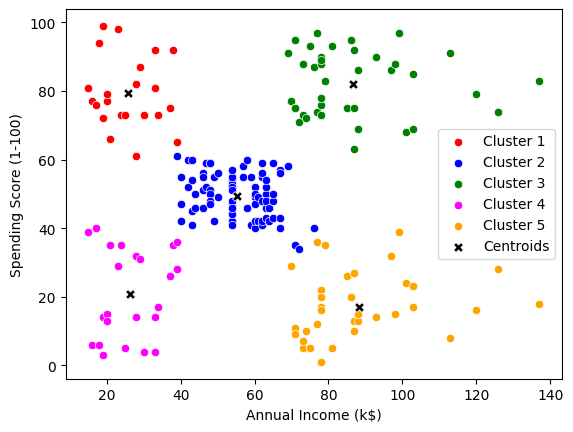

In [30]:
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'][betterClust.labels_ == 0],y=df1['Spending Score (1-100)'][betterClust.labels_ ==0],label='Cluster 1',c='red')
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'][betterClust.labels_ == 1],y=df1['Spending Score (1-100)'][betterClust.labels_ ==1],label='Cluster 2',c='blue')
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'][betterClust.labels_ == 2],y=df1['Spending Score (1-100)'][betterClust.labels_ ==2],label='Cluster 3',c='green')
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'][betterClust.labels_ == 3],y=df1['Spending Score (1-100)'][betterClust.labels_ ==3],label='Cluster 4',c='magenta')
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'][betterClust.labels_ == 4],y=df1['Spending Score (1-100)'][betterClust.labels_ ==4],label='Cluster 5',c='orange')
sns.scatterplot(data=betterClust.cluster_centers_,x=betterClust.cluster_centers_[:,0],y=betterClust.cluster_centers_[:,1],marker='X',s=50,label='Centroids',c='black')

Welcome to customer clustering!
Enter annual income120
Enter spending score15


/home/student/.local/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


New point belongs to cluster 5


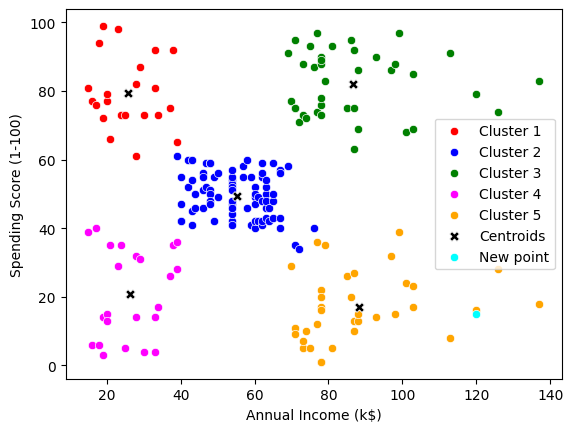

In [31]:
print('Welcome to customer clustering!')
AI =int(input('Enter annual income'))
SS = int(input('Enter spending score'))
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'][betterClust.labels_ == 0],y=df1['Spending Score (1-100)'][betterClust.labels_ ==0],label='Cluster 1',c='red')
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'][betterClust.labels_ == 1],y=df1['Spending Score (1-100)'][betterClust.labels_ ==1],label='Cluster 2',c='blue')
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'][betterClust.labels_ == 2],y=df1['Spending Score (1-100)'][betterClust.labels_ ==2],label='Cluster 3',c='green')
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'][betterClust.labels_ == 3],y=df1['Spending Score (1-100)'][betterClust.labels_ ==3],label='Cluster 4',c='magenta')
sns.scatterplot(data=df1,x=df1['Annual Income (k$)'][betterClust.labels_ == 4],y=df1['Spending Score (1-100)'][betterClust.labels_ ==4],label='Cluster 5',c='orange')
sns.scatterplot(data=betterClust.cluster_centers_,x=betterClust.cluster_centers_[:,0],y=betterClust.cluster_centers_[:,1],marker='X',s=50,label='Centroids',c='black')
sns.scatterplot(x=[AI],y=[SS],c='cyan',label='New point')
print("New point belongs to cluster",(betterClust.predict([[AI,SS]]))[0]+1)

In [32]:
aglo = AgglomerativeClustering(n_clusters=5)

In [33]:
aglo.fit(df1)

AgglomerativeClustering(n_clusters=5)

In [35]:
aglo.children_

array([[ 65,  68],
       [ 48,  49],
       [156, 158],
       [129, 131],
       [ 21,  23],
       [ 51,  53],
       [ 60,  61],
       [ 67,  69],
       [ 64,  66],
       [ 79,  82],
       [ 74,  85],
       [ 78,  80],
       [ 75,  81],
       [ 92,  97],
       [101, 109],
       [107, 113],
       [ 94,  98],
       [103, 104],
       [100, 105],
       [150, 154],
       [119, 120],
       [170, 174],
       [151, 155],
       [ 63, 200],
       [ 99, 213],
       [  3,   5],
       [ 26,  28],
       [ 40,  42],
       [ 10,  14],
       [ 54,  57],
       [ 58,  62],
       [ 70,  73],
       [ 91,  93],
       [108, 112],
       [126, 132],
       [137, 139],
       [147, 159],
       [ 77, 210],
       [ 76, 212],
       [149, 222],
       [ 12, 228],
       [116, 233],
       [ 13,  15],
       [  2,   6],
       [ 87,  90],
       [106, 110],
       [114, 115],
       [128, 130],
       [134, 136],
       [148, 152],
       [153, 157],
       [165, 171],
       [111,